In [2]:
import os
import sys
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

cau_package_path = "../"
_normpath = os.path.normpath(cau_package_path)
if not os.path.normpath(_normpath) in sys.path:
    sys.path.append(_normpath)

import cmb_anomaly_utils as cau

In [21]:
from matplotlib.lines import Line2D

plt.rcParams['text.usetex'] = True
plt.rc('font', family='serif')
plt.rc('legend', facecolor='white', edgecolor='k', framealpha=1)
plt.rcParams['xtick.major.size'] = 3.5
plt.rcParams['ytick.major.size'] = 3.5
plt.rcParams['xtick.labelsize']  = 12
plt.rcParams['ytick.labelsize']  = 12

def custom_save_fig(fig, fdir, fname, do_plt_save = False):
    cau.output.ensure_dir(fdir)
    for ftype in ['.png', '.pdf']:
        fpath    = fdir + fname + ftype
        if not do_plt_save:
            fig.savefig(fpath, facecolor=(1,1,1,0), dpi=300, transparent=True)
        else:
            plt.savefig(fpath, dpi = 300, transparent = True)

In [22]:
cleaning_pipeline               = "commander"
run_inputs  = cau.run_utils.RunInputs()
run_inputs.max_sim_num          = 1000
common_cmb_data_path            = "../"
run_inputs.mask_fpath           = "{}/input/cmb_fits_files/COM_Mask_CMB-common-Mask-Int_2048_R3.00.fits".format(common_cmb_data_path)
run_inputs.cmb_fpath            = "{}/input/cmb_fits_files/COM_CMB_IQU-{}_2048_R3.00_full.fits".format(common_cmb_data_path, cleaning_pipeline)
run_inputs.sims_path            = "{}/input/{}_sims/".format(common_cmb_data_path, cleaning_pipeline)
run_inputs.noise_path           = "{}/input/{}_noise/".format(common_cmb_data_path, cleaning_pipeline)
run_inputs.geom_flag            = cau.const.CAP_FLAG
run_inputs.measure_flag         = cau.const.VAR_FLAG
run_inputs.is_masked            = True
run_inputs.min_pix_ratio        = 0.2
run_inputs.nside                = 8
run_inputs.dir_nside            = 8
run_inputs.geom_start           = 0
run_inputs.geom_stop            = 180
run_inputs.delta_geom_samples   = 1
run_inputs.stripe_thickness     = 10
run_inputs.lmax                 = 30

base_path                       = "./output/{}_{}_min_pix_ratio_{:.1f}/".format(cleaning_pipeline, run_inputs.nside, run_inputs.min_pix_ratio)
plot_path                       = base_path.replace("output/", "plot/")
for _path in [base_path, plot_path]: cau.output.ensure_dir(_path)

map_disc_sizes = cau.stat_utils.get_range(10, 90, 10)
# map_disc_sizes = np.concatenate((cau.stat_utils.get_range(4, 9, 1), cau.stat_utils.get_range(10, 90, 5)))
max_sim_num = run_inputs.max_sim_num

### Reading foreground Map

2.3957872722727793e-12

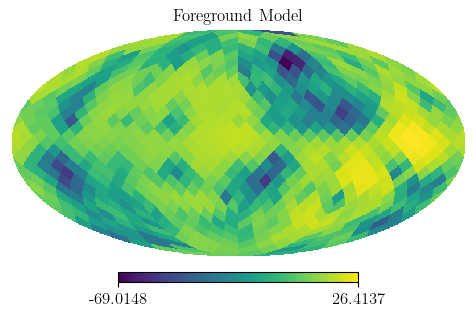

In [23]:
foreground_map = hp.read_map("./input/map_foreground_model_hansen2023_muK_ringordering_nside128.fits")
foreground_map = hp.ud_grade(foreground_map, run_inputs.nside)

fig = plt.figure(1, figsize=(5,3))
hp.mollview(foreground_map, fig, title = r"Foreground Model")
np.mean(foreground_map)

### Computing local variance maps

In [24]:
map_gen = cau.run_utils.MapGenerator(**run_inputs.to_kwargs())


print("Reading CMB Data:")
cmb_map = map_gen.create_cmb_map()
cau.map_utils.remove_monopole_dipole(cmb_map)
print("\t-Done-")

dir_lat, dir_lon = cau.coords.get_healpix_latlon(run_inputs.dir_nside)
ndir = cau.coords.get_npix(run_inputs.dir_nside)
measure_dir_indices = np.arange(ndir, dtype=int)

foreground_pix_map = map_gen.create_dummy_map()
foreground_pix_map.raw_data = foreground_map
foreground_pix_map.mask     = cmb_map.mask

cmb_measure = np.zeros(ndir)
foreground_measure = np.zeros(ndir)
subtracted_measure = np.zeros(ndir)

for disc_size in map_disc_sizes:
    print("Disc Size(deg): {:2}".format(disc_size))
    print("Calculating Cap Measures:")
    for dir_i in measure_dir_indices:
        print(f"\t{dir_i}/{ndir - 1}\r", end="")
        # Separating Common Geometry -> Top cap & Bottom cap
        plat, plon = dir_lat[dir_i], dir_lon[dir_i]
        foreground_pix_map.change_pole(plat, plon)
        top_filter, bottom_filter = cau.geometry.get_top_bottom_caps_selection_filters( pix_map = foreground_pix_map,
                                                                                        cap_angle = disc_size)
        # CMB measure
        top_cmb_cap, bottom_cmb_cap = cau.geometry.get_top_bottom_caps_by_filters( pix_map = cmb_map,
                                                                           top_sel = top_filter,
                                                                           bottom_sel = bottom_filter)
        visible_ratio = top_cmb_cap.get_visible_pixels_ratio()
        cmb_measure[dir_i] = \
            np.nan if visible_ratio < run_inputs.min_pix_ratio else \
                cau.measure.func_dict[run_inputs.measure_flag](top_cmb_cap, bottom_cmb_cap, **run_inputs.to_kwargs())
        # Foreground model measure
        top_fg_cap, bottom_fg_cap = cau.geometry.get_top_bottom_caps_by_filters( pix_map = foreground_pix_map,
                                                                           top_sel = top_filter,
                                                                           bottom_sel = bottom_filter)
        foreground_measure[dir_i] = \
            np.nan if visible_ratio < run_inputs.min_pix_ratio else \
                cau.measure.func_dict[run_inputs.measure_flag](top_fg_cap, bottom_fg_cap, **run_inputs.to_kwargs())
        # Subtracted local variance estimation 
        subtracted_measure[dir_i] = \
            np.nan if visible_ratio < run_inputs.min_pix_ratio else \
                np.var(top_cmb_cap.data - top_fg_cap.data)
                # cmb_measure[dir_i] + foreground_measure[dir_i]\
                #     - 2 * (np.mean(top_cmb_cap.data * top_fg_cap.data) - np.mean(top_cmb_cap.data) * np.mean(top_fg_cap.data))
    print("")
    
    _mflag = run_inputs.measure_flag.lower()
    _series = cleaning_pipeline
    np.savetxt(base_path + f"{_series}_cmb_{_mflag}_{disc_size:02}cap.txt", cmb_measure)
    np.savetxt(base_path + f"{_series}_foreground_{_mflag}_{disc_size:02}cap.txt", foreground_measure)
    np.savetxt(base_path + f"{_series}_subtracted_{_mflag}_{disc_size:02}cap.txt", subtracted_measure)

Reading CMB Data:
	-Done-
Disc Size(deg): 10.0
Calculating Cap Measures:
	767/767
Disc Size(deg): 20.0
Calculating Cap Measures:
	767/767
Disc Size(deg): 30.0
Calculating Cap Measures:
	767/767
Disc Size(deg): 40.0
Calculating Cap Measures:
	767/767
Disc Size(deg): 50.0
Calculating Cap Measures:
	767/767
Disc Size(deg): 60.0
Calculating Cap Measures:
	767/767
Disc Size(deg): 70.0
Calculating Cap Measures:
	767/767
Disc Size(deg): 80.0
Calculating Cap Measures:
	767/767
Disc Size(deg): 90.0
Calculating Cap Measures:
	767/767


### Plot raw local variances

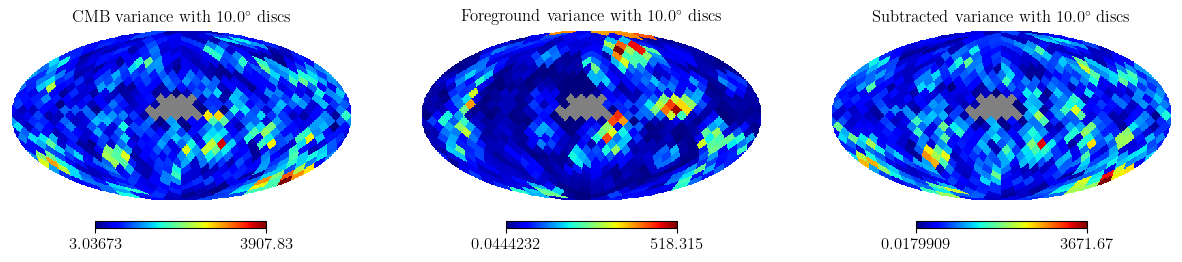

CMB  :  99.34757099973908
Foreground  :  26.52330632265523
Suntracted Map  :  106.30833658060399


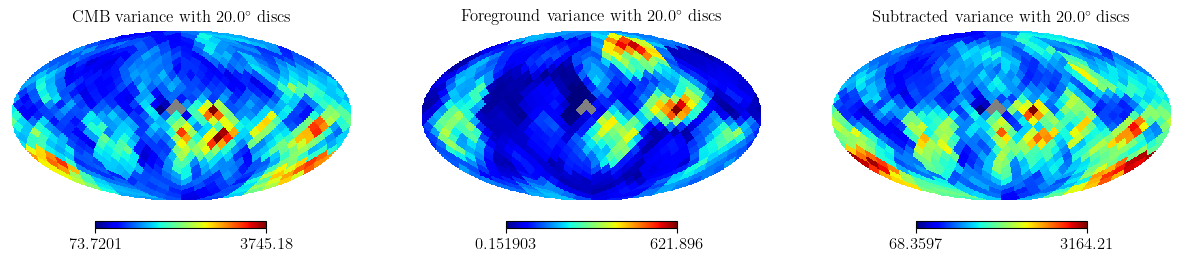

CMB  :  96.95127692496551
Foreground  :  29.574998935680547
Suntracted Map  :  103.1544814834042


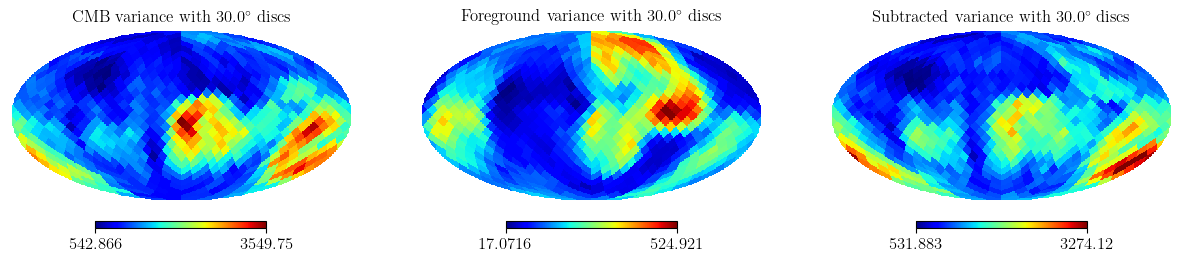

CMB  :  95.60420596943639
Foreground  :  31.95532319513488
Suntracted Map  :  101.20311645465665


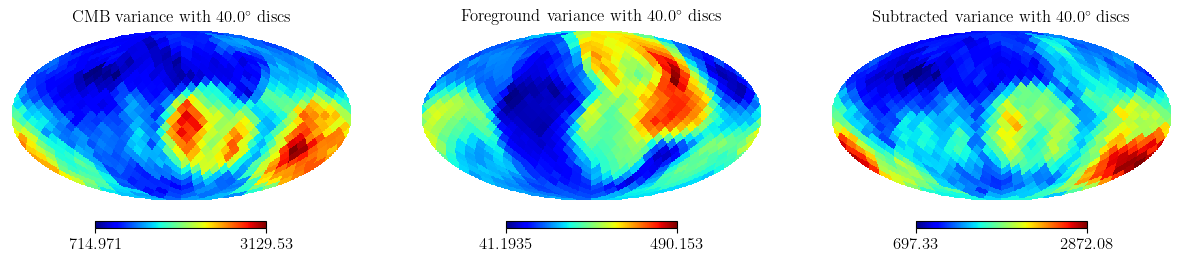

CMB  :  94.51654867205312
Foreground  :  32.011757167855926
Suntracted Map  :  100.4677961357275


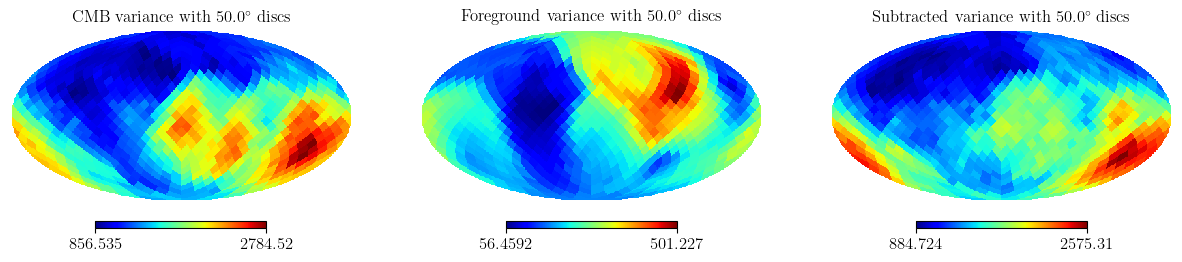

CMB  :  93.60848922329794
Foreground  :  30.672898347004423
Suntracted Map  :  99.81113763949473


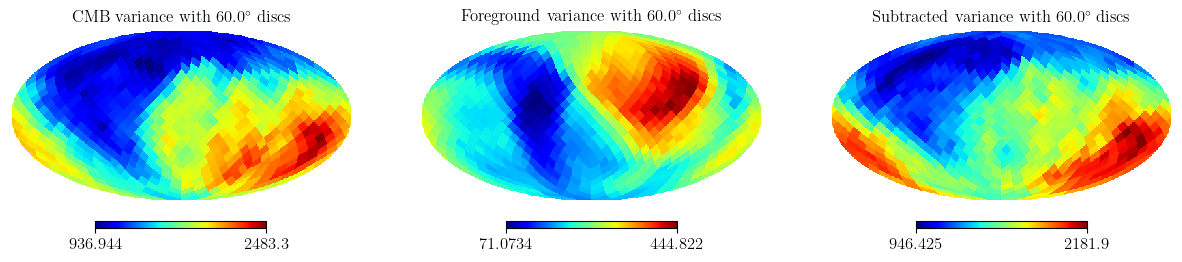

CMB  :  92.21449869723239
Foreground  :  30.527478711319425
Suntracted Map  :  98.60215755881067


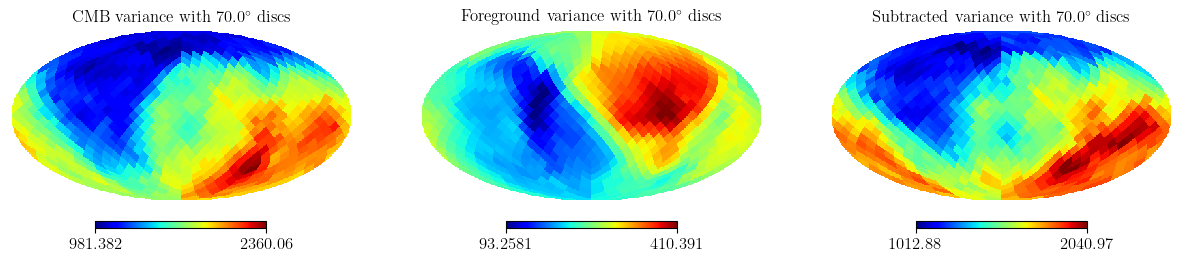

CMB  :  92.44709861516306
Foreground  :  30.09191797141801
Suntracted Map  :  98.28512856586707


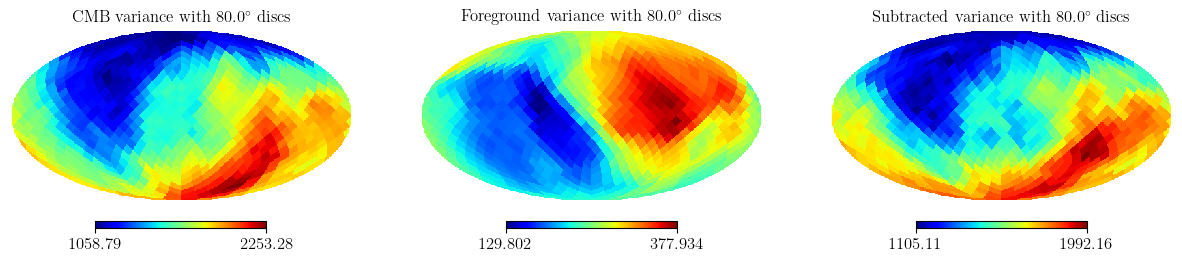

CMB  :  93.3189981362528
Foreground  :  29.464318931224746
Suntracted Map  :  98.56818263918626


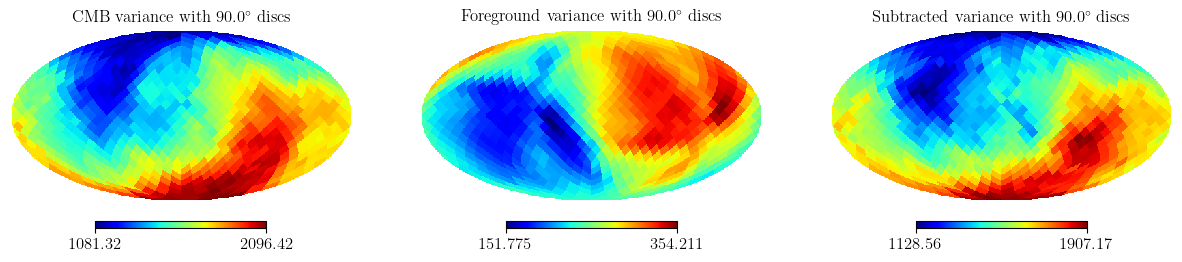

CMB  :  93.7296791227484
Foreground  :  29.08348336399499
Suntracted Map  :  98.6427398062436


In [25]:
_mflag = run_inputs.measure_flag.lower()
_series = cleaning_pipeline
dir_lat, dir_lon = cau.coords.get_healpix_latlon(run_inputs.dir_nside)

doppler_dir = cau.coords.convert_polar_to_xyz(48.26, 263.99)[0]

for disc_size in map_disc_sizes:
    #CMB measure
    '''cmb_msr'''
    cmb_msr             = np.loadtxt(base_path + f"{_series}_cmb_{_mflag}_{disc_size:02}cap.txt")
    foreground_msr      = np.loadtxt(base_path + f"{_series}_foreground_{_mflag}_{disc_size:02}cap.txt")
    subtracted_msr      = np.loadtxt(base_path + f"{_series}_subtracted_{_mflag}_{disc_size:02}cap.txt")

    # mean_field = np.mean(sims_msr, axis = 0)
    # var_msr = np.var(sims_msr, axis = 0)
    # local_msr_map = (sims_local_msr_map[700] - mean_field) / var_msr
    
    _fig, (ax1, ax2, ax3) = plt.subplots(ncols=3)

    _fig.set_size_inches(15,5)

    plt.axes(ax1)
    hp.mollview(cmb_msr,
                title = r"CMB variance with ${}^\circ$ discs".format(disc_size),
                cmap = "jet",
                xsize = 500,
                # fontsize = dict(title = 20,
                #                 cbar_tick_label = 15,),
                hold=True
                )
    plt.axes(ax2)
    hp.mollview(foreground_msr,
                title = r"Foreground variance with ${}^\circ$ discs".format(disc_size),
                cmap = "jet",
                xsize = 500,
    #             fontsize = dict(title = 20,
    #                             cbar_tick_label = 15),
                hold=True
                )
    plt.axes(ax3)
    hp.mollview(subtracted_msr,#cmb_msr - foreground_msr,
                title = r"Subtracted variance with ${}^\circ$ discs".format(disc_size),
                cmap = "jet",
                xsize = 500,
                hold=True
                )
    custom_save_fig(_fig, fdir=plot_path, fname=f"cmb_variance_subtract_foreground_{disc_size}",do_plt_save=True)
    plt.show()
    def get_normalized_vec(vec):
        return vec / np.sqrt(np.dot(vec, vec))
    def get_angle_between(v1, v2):
        return np.degrees(np.arccos(np.dot(get_normalized_vec(v1), get_normalized_vec(v2))))

    for _res in zip([cmb_msr, foreground_msr, subtracted_msr],["CMB", "Foreground", "Suntracted Map"]):
        _msr, _label = _res[0], _res[1]
        dipole_dir = (hp.fit_dipole(_msr))[1]
        deviation_from_doppler = get_angle_between(dipole_dir, doppler_dir)
        # print(get_normalized_vec(dipole_dir), get_normalized_vec(doppler_dir))
        print(_label, " : " ,deviation_from_doppler)

#### Finding Dipole Direction/Amplitude on Cap-Measure Maps Considering $Mean(Measure) \; \& \; Var(Measure)$
    "Calculate Cap (RAW)Measures" Section has to be computed and stored

In [20]:
n_cap_sizes = len(map_disc_sizes)

# The directions that we measure towards
cmb_directions          = np.zeros(n_cap_sizes)
foreground_directions   = np.zeros(n_cap_sizes)
cmb_amplitides          = np.zeros(n_cap_sizes)
foreground_amplitudes   = np.zeros(n_cap_sizes)
sub_field_amplitudes    = np.zeros(n_cap_sizes)

dummy_map = cau.dtypes.PixMap.create_dummy(run_inputs.dir_nside)

_mflag = run_inputs.measure_flag.lower()
_series = cleaning_pipeline
_precomputed_path = "../cmb_local_variance_higher_multipoles/output/commander_64_min_pix_ratio_0.1/"
for ds_i, disc_size in enumerate(map_disc_sizes):
    cmb_msr         = np.loadtxt(_precomputed_path + f"{_series}_cmb_{_mflag}_{disc_size:02}cap.txt")
    sims_msr        = np.loadtxt(_precomputed_path + f"{_series}_sims_{_mflag}_{disc_size:02}cap.txt")
    foreground_msr  = np.loadtxt(base_path + f"{_series}_foreground_{_mflag}_{disc_size:02}cap.txt")

    #----COMMON ASSETS----
    # Common Mean and Var of Simulated Maps
    _mean = np.mean(sims_msr, axis = 0)
    _var  = np.var(sims_msr, axis = 0)
    # Common Mask
    _mask = np.isnan(cmb_msr)
    dummy_map.mask = _mask if np.any(_mask) else None
    
    #----SPECIFIC CALCULATIONS----
    # CMB Dipole
    dummy_map.data = (cmb_msr - _mean) / _var
    cmb_directions[ds_i] = cau.map_utils.get_dipole_direction_index(pix_map = dummy_map,
                                                                    dir_nside = run_inputs.dir_nside)
    cmb_amplitides[ds_i] = cau.map_utils.get_dipole_amplitude(pix_map=dummy_map)
    # Foreground Dipole
    dummy_map.data = (foreground_msr - _mean) / _var
    foreground_directions[ds_i] = \
        cau.map_utils.get_dipole_direction_index(pix_map = dummy_map,
                                                 dir_nside = run_inputs.dir_nside)
    foreground_amplitudes[ds_i] = cau.map_utils.get_dipole_amplitude(pix_map=dummy_map)
    # Subtracted Field Dipole
    dummy_map.data = (cmb_msr - foreground_msr - _mean) / _var
    sub_field_amplitudes[ds_i] = cau.map_utils.get_dipole_amplitude(pix_map=dummy_map)
    

np.savetxt(base_path + f"{_series}_cmb_{_mflag}_dir.txt", cmb_directions, fmt = '%i')
np.savetxt(base_path + f"{_series}_foreground_{_mflag}_dir.txt", foreground_directions, fmt = '%i')


np.savetxt(base_path + f"{_series}_cmb_{_mflag}_amp.txt", cmb_amplitides)
np.savetxt(base_path + f"{_series}_foreground_{_mflag}_amp.txt", foreground_amplitudes)
np.savetxt(base_path + f"{_series}_subfield_{_mflag}_amp.txt", sub_field_amplitudes)

ValueError: operands could not be broadcast together with shapes (768,) (3072,) 

In [17]:
base_path + f"{_series}_subfield_{_mflag}_amp.txt"

'./output/commander_64_min_pix_ratio_0.1/commander_subfield_var_amp.txt'

In [1]:
_theta = np.pi / 180 * run_inputs.geom_range

# Akrami2014 dipole amplitude
cmb_dip_amp = np.loadtxt(base_path + "{}_cmb_var_amp.txt".format(cleaning_pipeline))

sim_base_path = '../cmb_local_variance_higher_multipoles/output/commander_64_min_pix_ratio_0.1/'
sims_dip_amp = np.loadtxt(sim_base_path + "{}_sims_var_amp.txt".format(cleaning_pipeline))

sub_dip_amp = np.loadtxt(base_path + "{}_subfield_var_amp.txt".format(cleaning_pipeline))

print(sub_dip_amp)

with plt.style.context('bmh'):
    x_offset = 0.6
    fig, ax = plt.subplots()
    # Akrami2014 Plot
    for ds_i, disc_size in enumerate(map_disc_sizes):
        ax.scatter(disc_size * np.ones(run_inputs.max_sim_num) - x_offset, sims_dip_amp[ds_i],
                    marker='.', edgecolors='none', linewidths=.5, c='cadetblue', alpha=1)
    ax.plot(map_disc_sizes, cmb_dip_amp,
            color='darkorange', marker='D', markersize=5, linewidth=1.5)
    ax.plot(map_disc_sizes, sub_dip_amp,
            color='darkgreen', marker='D', markersize=5, linewidth=1.5)
    
    ax.set_xlabel(r"Disc size for map creation $(^\circ)$")
    ax.set_ylabel(r"Dipole Amplitude")
    # ax.set_title(r"Comparison between stripe-mean Legendre dipole \& Dipole fitting")
    sample_curves = [
        Line2D([0], [0], ls='-',    color='orange',     lw=1, marker='D', markersize=5),
        Line2D([0], [0], ls='none', color='cadetblue',  lw=1, marker='.', markersize=10),
        Line2D([0], [0], ls='-',    color='green',     lw=1, marker='D', markersize=5),
        ]
    ax.legend(  sample_curves,
                [   r"Dipole Amplitude of $\sigma^2_{\mathrm{CMB}}$",
                    r"Dipole Amplitude of $\sigma^2_{\mathrm{Sims}}$",
                    r"Dipole Amplitude of $\sigma^2_{\mathrm{CMB}} - \sigma^2_{\mathrm{Foreground}}$"],
                loc=2)
    ax.tick_params(axis='x', which='major', labelsize=10)
    ax.set_xlim(xmin = 0, xmax = 95)
    ax.set_xticks(map_disc_sizes)
    ax.set_facecolor('white')
    # Axis colors
    for spine in ax.spines.keys(): ax.spines[spine].set_color('k')
    plt.show()
    custom_save_fig(fig, fdir = plot_path, fname = "dipole_amplitude_df_Legendre_comparison")

NameError: name 'np' is not defined

### Taking stripes and computing P_l

In [17]:
# New settings for taking stripes
run_inputs.measure_flag     = cau.const.VAR_FLAG

# Common PixMap
dummy_map = cau.dtypes.PixMap.create_dummy(run_inputs.dir_nside)
# Read computed measures
_mflag = run_inputs.measure_flag.lower()
_series = cleaning_pipeline

cmb_directions          = np.loadtxt(base_path + f"{_series}_cmb_{_mflag}_dir.txt", dtype=int)
foreground_directions   = np.loadtxt(base_path + f"{_series}_foreground_{_mflag}_dir.txt", dtype=int)
dir_lat, dir_lon = cau.coords.get_healpix_latlon(run_inputs.dir_nside)

# New settings for taking stripes
run_inputs.geom_flag        = cau.const.STRIPE_FLAG
run_inputs.measure_flag     = cau.const.MEAN_FLAG
run_inputs.stripe_thickness = 10

# We also calculate dipole with healpy fit_dipole routine to see the difference of methods
cmb_dipole_amp  = 0
sims_dipole_amp = np.zeros(run_inputs.max_sim_num)

cmb_stripe_mean  = np.zeros(len(run_inputs.geom_range))
foreground_stripe_mean = np.zeros((max_sim_num, len(run_inputs.geom_range)))

for ds_i, disc_size in enumerate(map_disc_sizes[:2]):
    cmb_msr    = np.loadtxt(_precomputed_path + f"{_series}_cmb_{_mflag}_{disc_size:02}cap.txt")
    sims_msr   = np.loadtxt(_precomputed_path + f"{_series}_sims_{_mflag}_{disc_size:02}cap.txt")
    foreground_msr  = np.loadtxt(base_path + f"{_series}_foreground_{_mflag}_{disc_size:02}cap.txt")

    # Find Mean Field
    mean_field = np.mean(sims_msr, axis = 0)
    var_msr = np.var(sims_msr, axis = 0)
    # Set Mask
    dummy_map.mask = np.isnan(cmb_msr)
    # Calculation for CMB
    cmb_data = (cmb_msr - mean_field) / var_msr
    dummy_map.raw_data = cmb_data
    dir_index  = cmb_directions[ds_i]
    plat, plon = dir_lat[dir_index], dir_lon[dir_index]
    dummy_map.change_pole(plat, plon)
    cmb_stripe_mean = cau.measure.get_measure(dummy_map, **run_inputs.to_kwargs())
    cmb_dipole_amp = cau.map_utils.get_dipole_amplitude(dummy_map)

    # Calculation for Foreground model
    dummy_map.raw_data = (foreground_msr - _mean) / _var
    dir_index  = foreground_directions[ds_i]
    plat, plon = dir_lat[dir_index], dir_lon[dir_index]
    dummy_map.change_pole(plat, plon)
    foreground_stripe_mean = cau.measure.get_measure(dummy_map, **run_inputs.to_kwargs())
    foreground_dipole_amp = cau.map_utils.get_dipole_amplitude(dummy_map)
    

    _stripe_size = run_inputs.stripe_thickness
    f"{_series}_cmb_{_stripe_size:02}stripe_{_mflag}mean_{disc_size:02}cap.txt"
    np.savetxt( base_path + f"{_series}_cmb_{_stripe_size:02}stripe_{_mflag}mean_{disc_size:02}cap.txt",
                cmb_stripe_mean,
                comments = str(cmb_dipole_amp))
    np.savetxt( base_path + f"{_series}_foreground_{_stripe_size:02}stripe_{_mflag}mean_{disc_size:02}cap.txt",
                foreground_stripe_mean,
                comments = str(foreground_dipole_amp))

### Computing/Plotting $P_\ell$

[-8.42461377 -8.42461377 -8.42461377 -8.38968323 -8.35251116 -8.34677205
 -8.34677205 -8.38457625 -8.37605353 -8.32858353 -8.30483604 -8.36810613
 -8.30777166 -8.29512831 -8.33861797 -8.33664105 -8.31761672 -8.37178096
 -8.35335375 -8.31697291 -8.38003426 -8.29463623 -8.31878583 -8.20043908
 -8.25122876 -8.19832969 -8.06820068 -8.1905273  -8.22940861 -8.09660506
 -8.25064511 -8.21661496 -8.28776211 -8.25350459 -8.2405491  -8.3615973
 -8.22304657 -8.24777408 -8.36271521 -8.26333248 -8.44078424 -8.39138993
 -8.20314369 -8.32669406 -8.16431669 -8.1015055  -7.67227916         nan
         nan -7.67349212 -7.77642925         nan -8.22743431 -7.97261059
 -8.01166293         nan -8.42284008 -8.07097956 -8.40773947 -8.39307492
 -8.38949985 -8.50137293 -8.37359323 -8.50047867         nan -8.44860945
 -8.38888467 -8.4112475  -8.33204102         nan -8.40999602         nan
 -8.3285946  -8.26666105 -8.2708677          nan         nan -8.15944537
 -8.22750572 -8.35410519         nan -8.19918131 -8.

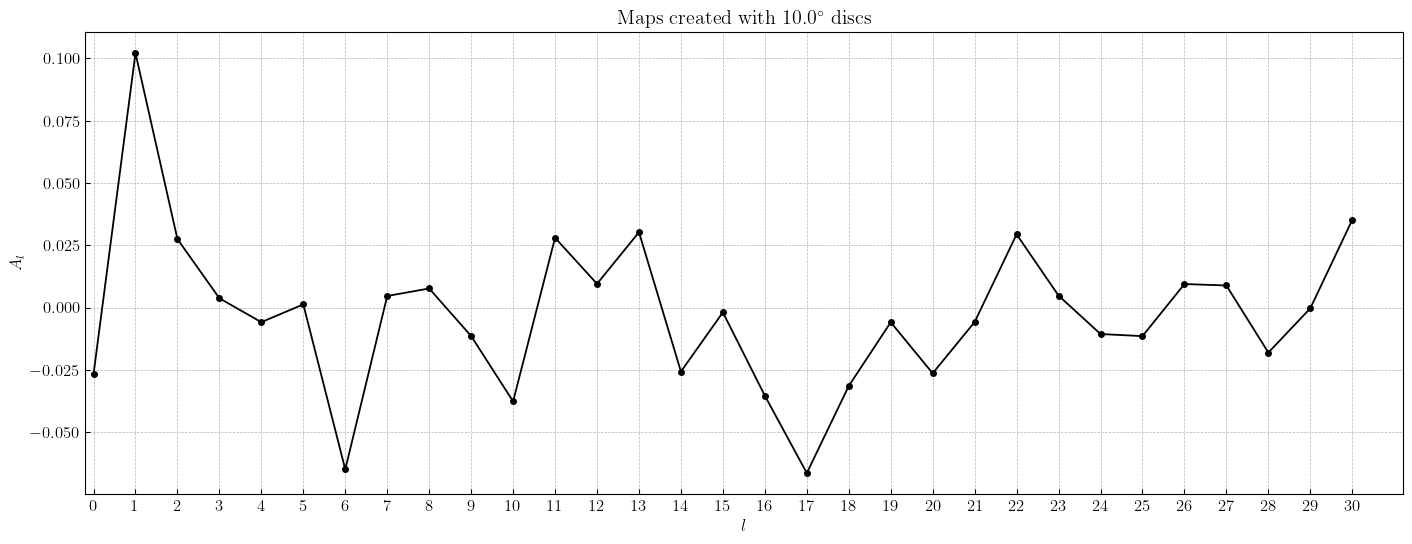

In [22]:
_theta = np.pi / 180 * run_inputs.geom_range
lrange = np.arange(run_inputs.lmax + 1)
p_values = np.zeros(len(lrange))
sims_a_l = np.zeros((run_inputs.max_sim_num, len(lrange)))


_mflag = cau.const.VAR_FLAG.lower()
_series = cleaning_pipeline
_stripe_size = run_inputs.stripe_thickness


with plt.style.context('bmh'):
    for disc_size in map_disc_sizes[:1]:
        fig, ax=plt.subplots()
        fig.set_size_inches(17,6)
        cmb_measure  = np.loadtxt(_precomputed_path + f"{_series}_cmb_{_stripe_size:02}stripe_{_mflag}mean_{disc_size:02}cap.txt")
        sims_measure = np.loadtxt(_precomputed_path + f"{_series}_sims_{_stripe_size:02}stripe_{_mflag}mean_{disc_size:02}cap.txt")
        foreground_measure = np.loadtxt(base_path + f"{_series}_foreground_{_stripe_size:02}stripe_{_mflag}mean_{disc_size:02}cap.txt")

        print(foreground_measure)
        # Calculate A_l's
        cmb_a_l = cau.math_utils.get_all_legendre_coefs(_theta, cmb_measure, run_inputs.lmax)
        foreground_a_l = cau.math_utils.get_all_legendre_coefs(_theta, foreground_measure, run_inputs.lmax)
        # for sim_num in range(run_inputs.max_sim_num):
        #     sims_a_l[sim_num] = cau.math_utils.get_all_legendre_coefs(_theta, sims_measure[sim_num], run_inputs.lmax)
        # Calculate P-values
        # a_l_mean = np.nanmean(sims_a_l, axis=0)
        # for ell in lrange:
        #     if cmb_a_l[ell] > a_l_mean[ell]:
        #         p_values[ell] = np.sum(sims_a_l[:, ell] >= cmb_a_l[ell]) / run_inputs.max_sim_num
        #     else:
        #         p_values[ell] = np.sum(sims_a_l[:, ell] < cmb_a_l[ell]) / run_inputs.max_sim_num
        
        # Plot
        # for sim_num in range(run_inputs.max_sim_num):
        #     ax.scatter(lrange, sims_a_l[sim_num],
        #                marker='.', edgecolors='none', linewidths=.5, c='green', alpha=1)
        
        # a_l_max = np.nanmax(sims_a_l, axis=0)
        # for ell in lrange:
        #     y_plus_offset = 0.004
        #     y_minus_offset = 0.008
        #     if ell < len(lrange) - 1 and cmb_a_l[ell + 1] > cmb_a_l[ell]:
        #         ypos = cmb_a_l[ell] - y_minus_offset
        #     else:
        #         ypos = cmb_a_l[ell] + y_plus_offset
        #     ax.text(x=ell + 0.1, y = ypos, s = "{:0.3f}".format(p_values[ell]))
        ax.plot(lrange, cmb_a_l,
                color='k', linewidth=1.3, marker='o', markersize=4)
        ax.plot(lrange, foreground_a_l,
                color='b', linewidth=1.3, marker='o', markersize=4)

        ax.set_xlabel(r"$l$")
        ax.set_ylabel(r"$A_l$")
        ax.set_title(r"Maps created with ${cap_size}^\circ$ discs".format(cap_size = disc_size))
        ax.set_xlim(xmin = 0 - 0.2, xmax = run_inputs.lmax + 1 + 0.2)
        ax.set_xticks(lrange)
        # ax.set_aspect(100)
        ax.set_facecolor('white')
        # Axis colors
        for spine in ax.spines.keys(): ax.spines[spine].set_color('k')
        plt.show()
        custom_save_fig(fig, fdir = plot_path + "plots/", fname = "{}_{:02}stripe_{}mean_a_l_{:02}cap".format(cleaning_pipeline, run_inputs.stripe_thickness, _mflag, disc_size))
        
        np.savetxt(base_path + "{}_{:02}stripe_{}mean_cmb_a_l_{:02}cap.txt".format(cleaning_pipeline, run_inputs.stripe_thickness, _mflag, disc_size), cmb_a_l)
        np.savetxt(base_path + "{}_{:02}stripe_{}mean_sims_a_l_{:02}cap.txt".format(cleaning_pipeline, run_inputs.stripe_thickness, _mflag, disc_size), sims_a_l)